In [1]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV


##### 데이터 로드
---

In [2]:
from sklearn.datasets import load_wine

wine_data = load_wine(as_frame=True)

wine_input = wine_data['data'].values
wine_target = wine_data.target

In [9]:
print(wine_target.unique())
print(wine_input.columns)

[0 1 2]
Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='str')


- Alcohol: 알코올 도수
- Malic acid: 말산 (사과산, 와인의 신맛을 내는 주요 유기산)
- Ash: 회분 (와인을 태우고 남은 무기물 잔여물)
- Alcalinity of ash: 회분의 알칼리도
- Magnesium: 마그네슘 함량
- Total phenols: 총 페놀 (항산화 물질이자 와인의 떫은맛과 색을 결정)
- Flavanoids: 플라보노이드 (페놀 화합물의 일종)
- Nonflavanoid phenols: 비플라보노이드계 페놀
- Proanthocyanins: 프로안토시아닌 (탄닌의 일종, 떫고 쌉싸름한 맛)
- Color intensity: 와인의 색상 강도 (짙은 정도)
- Hue: 와인의 색조 (색상의 종류 및 숙성 정도)
- OD280/OD315 of diluted wines: 희석된 와인의 단백질 측정값
- Proline: 프롤린 (아미노산의 일종)

In [3]:
# 분류 문제에서는 보통 클래스 비율을 유지하기 위해 stratify=wine_target 추가
# 데이터 나누기
train_wine, test_wine, train_target, test_target = train_test_split(
    wine_input, wine_target, random_state=42, stratify=wine_target
)

In [4]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


# 교차 검증을 위한 모델 파이프라인

# 모델 딕셔너리 만들기

models = {
    'LogisticRegression' : Pipeline([
        ('scaler', StandardScaler()),
        ('model',LogisticRegression(max_iter=1000, random_state=42))
    ]),

    'SGDClassifier' : Pipeline([
        ('scaler', StandardScaler()),
        ('model',SGDClassifier(loss='log_loss', random_state=42))
    ]),

    'DecisionTree' : Pipeline([
        ('model',DecisionTreeClassifier(random_state=42))
    ]),

    'RandomForest' : Pipeline([
        ('model',RandomForestClassifier(random_state=42, n_jobs=-1))
    ]),

    'XGBoost' : Pipeline([
        ('model',XGBClassifier(random_state=42, eval_metric='logloss'))
    ])
}


In [5]:
# 여러 지표 함께 보기
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_ovr']

result = []

for name, model in models.items() :
    scores = cross_validate(
        model,
        train_wine, train_target,
        cv=5,
        return_train_score=True,
        scoring=scoring
    )

    result.append({
        'model' : name,
        'train_accuracy' : scores['train_accuracy'].mean(),
        'test_accuracy' : scores['test_accuracy'].mean(),
        'test_precision' : scores['test_precision_macro'].mean(),
        'test_recall' : scores['test_recall_macro'].mean(),
        'test_f1' : scores['test_f1_macro'].mean(),
        'test_roc_auc' : scores['test_roc_auc_ovr'].mean(),
        'accuracy_gap' : scores['train_accuracy'].mean() - scores['test_accuracy'].mean(),
        'fit_time' : scores['fit_time'].mean()
    })

result_df = pd.DataFrame(result)
result_df.sort_values('test_f1', ascending=False)

,model,train_accuracy,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,accuracy_gap,fit_time
0,LogisticRegression,1.0,0.984900,0.985000,0.987273,0.985363,0.999608,0.015100,0.005908
1,SGDClassifier,1.0,0.977208,0.978939,0.979865,0.978267,0.998703,0.022792,0.003729
3,RandomForest,1.0,0.969801,0.970606,0.973805,0.970648,0.999621,0.030199,0.113952
4,XGBoost,1.0,0.932479,0.937429,0.937345,0.934503,0.994528,0.067521,0.046560
2,DecisionTree,1.0,0.895442,0.907294,0.900279,0.898862,0.923202,0.104558,0.001288


- 모든 모델의 정확도가 1에 가까운 수치로 분별력 없음.
- 트리 모델의 max_depth 값 확인 필요성

##### 트리모델 max_depth 설정값 확인
---

In [6]:
for name, model in models.items():
    estimator = model['model']
    if hasattr(estimator, 'max_depth'):
        print(f"{name}의 기본 max_depth: {estimator.max_depth}")
    else:
        pass
    
    

DecisionTree의 기본 max_depth: None
RandomForest의 기본 max_depth: None
XGBoost의 기본 max_depth: None


##### GridSearchCV 최적의 depth 찾기
---

In [7]:
tree_pipe = Pipeline([
    ('model', DecisionTreeClassifier(random_state=42))
])

tree_param_grid = [
    {
        'model': [DecisionTreeClassifier(random_state=42)],
        'model__max_depth': [1, 2, 3, 4, 5, None],
        'model__min_samples_leaf': [1, 2, 3, 5],
        'model__criterion': ['gini', 'entropy']
    },

    {
        'model': [RandomForestClassifier(random_state=42, n_jobs=1)],
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [2, 3, 4, 5, None],
        'model__min_samples_leaf': [1, 2, 3, 5]
    },

    {
        'model': [XGBClassifier(
            random_state=42,
            eval_metric='mlogloss',
            n_jobs=1
        )],
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [2, 3, 4, 5],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__subsample': [0.8, 1.0]
    }
]

tree_gs = GridSearchCV(
    tree_pipe,
    tree_param_grid,
    cv=5,
    scoring='f1_macro',
    return_train_score=True
)

tree_gs.fit(train_wine, train_target)

print('best params:', tree_gs.best_params_)
print('best score:', tree_gs.best_score_)

best params: {'model': RandomForestClassifier(n_jobs=1, random_state=42), 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__n_estimators': 50}
best score: 0.9709694691273638


In [8]:
tree_result_df = pd.DataFrame(tree_gs.cv_results_)

cols = [
    'rank_test_score',
    'mean_train_score',
    'mean_test_score',
    'std_test_score',
    'mean_fit_time',
    'param_model',
    'param_model__max_depth',
    'param_model__min_samples_leaf',
    'param_model__n_estimators',
    'param_model__learning_rate',
    'param_model__subsample',
    'params'
]

tree_result_df[cols].sort_values('rank_test_score').head(5)

,rank_test_score,mean_train_score,mean_test_score,std_test_score,mean_fit_time,param_model,param_model__max_depth,param_model__min_samples_leaf,param_model__n_estimators,param_model__learning_rate,param_model__subsample,params
54,1,0.996516,0.970969,0.027012,0.047683,"RandomForestClassifier(n_jobs=1, random_state=42)",2,3.0,50.0,NaN,NaN,"{'model': RandomForestClassifier(n_jobs=1, ran..."
48,1,0.998258,0.970969,0.027012,0.047906,"RandomForestClassifier(n_jobs=1, random_state=42)",2,1.0,50.0,NaN,NaN,"{'model': RandomForestClassifier(n_jobs=1, ran..."
51,1,0.998258,0.970969,0.027012,0.047637,"RandomForestClassifier(n_jobs=1, random_state=42)",2,2.0,50.0,NaN,NaN,"{'model': RandomForestClassifier(n_jobs=1, ran..."
50,4,0.990696,0.970648,0.014730,0.186848,"RandomForestClassifier(n_jobs=1, random_state=42)",2,1.0,200.0,NaN,NaN,"{'model': RandomForestClassifier(n_jobs=1, ran..."
58,4,0.988979,0.970648,0.014730,0.093886,"RandomForestClassifier(n_jobs=1, random_state=42)",2,5.0,100.0,NaN,NaN,"{'model': RandomForestClassifier(n_jobs=1, ran..."


In [10]:
tree_result_df['model_name'] = tree_result_df['param_model'].apply(
    lambda x: type(x).__name__
)

tree_result_df[
    [
        'rank_test_score',
        'model_name',
        'mean_train_score',
        'mean_test_score',
        'std_test_score',
        'param_model__max_depth',
        'param_model__min_samples_leaf',
        'param_model__n_estimators',
        'param_model__learning_rate',
        'param_model__subsample'
    ]
].sort_values('rank_test_score').head(5)

,rank_test_score,model_name,mean_train_score,mean_test_score,std_test_score,param_model__max_depth,param_model__min_samples_leaf,param_model__n_estimators,param_model__learning_rate,param_model__subsample
54,1,RandomForestClassifier,0.996516,0.970969,0.027012,2,3.0,50.0,NaN,NaN
48,1,RandomForestClassifier,0.998258,0.970969,0.027012,2,1.0,50.0,NaN,NaN
51,1,RandomForestClassifier,0.998258,0.970969,0.027012,2,2.0,50.0,NaN,NaN
50,4,RandomForestClassifier,0.990696,0.970648,0.014730,2,1.0,200.0,NaN,NaN
58,4,RandomForestClassifier,0.988979,0.970648,0.014730,2,5.0,100.0,NaN,NaN


In [11]:
tree_result_df['gap'] = (
    tree_result_df['mean_train_score'] - tree_result_df['mean_test_score']
)

tree_result_df[
    [
        'rank_test_score',
        'model_name',
        'mean_train_score',
        'mean_test_score',
        'gap',
        'param_model__max_depth',
        'param_model__min_samples_leaf',
        'param_model__n_estimators',
        'param_model__learning_rate'
    ]
].sort_values('rank_test_score').head(5)

,rank_test_score,model_name,mean_train_score,mean_test_score,gap,param_model__max_depth,param_model__min_samples_leaf,param_model__n_estimators,param_model__learning_rate
54,1,RandomForestClassifier,0.996516,0.970969,0.025546,2,3.0,50.0,NaN
48,1,RandomForestClassifier,0.998258,0.970969,0.027288,2,1.0,50.0,NaN
51,1,RandomForestClassifier,0.998258,0.970969,0.027288,2,2.0,50.0,NaN
50,4,RandomForestClassifier,0.990696,0.970648,0.020048,2,1.0,200.0,NaN
58,4,RandomForestClassifier,0.988979,0.970648,0.018331,2,5.0,100.0,NaN


In [12]:
best_tree_model = tree_gs.best_estimator_

print('train score:', best_tree_model.score(train_wine, train_target))
print('test score:', best_tree_model.score(test_wine, test_target))

train score: 0.9849624060150376
test score: 0.9555555555555556


In [ ]:
from sklearn.metrics import f1_score, accuracy_score, classification_report

pred = best_tree_model.predict(test_wine)

print('accuracy:', accuracy_score(test_target, pred))
print('f1_macro:', f1_score(test_target, pred, average='macro'))
print(classification_report(test_target, pred))

accuracy: 0.9555555555555556
f1_macro: 0.9563061353573689
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      0.89      0.94        18
           2       0.92      1.00      0.96        12

    accuracy                           0.96        45
   macro avg       0.95      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [14]:
np.unique(wine_target, return_counts=True)

(array([0, 1, 2]), array([59, 71, 48]))

- 왜 이렇게 잘나왔을까?
- load_wine은 애초에 깨끗한 데이터셋( 3개 품종 분류 ) : 학습용 예제 데이터로 결측치, 이상치, 노이즈 별로 없음
- feature의 화학 성분들이 품종별로 잘 갈라지는 편이라 선형 모델도 잘 맞는 편
- 데이터 크기가 작음
- test_train split 기준 - 45 / 133개 : 실전도 완벽하다 보다는 테스트에서 다 맞출 수 있었다로 해석

- 특히 선형 모델의 결과가 트리 모델보다 더 잘 나온 것은 이 데이터는 복잡한 비선형 모델이 아니어도 충분히 잘 분리된다고 볼 수 있음.
---
- stratify=wine_target 추가 여부에 따라 달라진 결과?
    - load_wine는 3개 클래스 [59, 71, 48]
    - 데이터가 적은 상태에서 stratify 조건 없이 나눴을 때 결과에 영향을 미칠 수 있다.
- LogisticRegression 과 SGD간의 경쟁
    - LogisticRegression : 전체 데이터를 기준으로 비교적 안정적으로 최적화
    - SGDClassifier : 데이터를 조금씩 보면서 확률적 경사하강법으로 최적화(대용량 데이터에서 장점)
    - 작은 데이터셋에서는 LogisticRegression이 더 안정적으로 나오는 경우가 많다.
- DecisionTree : 데이터가 작을 때 분할에 민감
```text
feature <= 특정 값
feature <= 특정 값
feature <= 특정 값
```
- train 데이터에서 잘 먹힌 기준이 test에서 잘 안먹힐 수 있음.
---

#### 랜덤포레스트 학습 & 피처 중요도 보기
---

In [16]:
feature_names = wine_data.data.columns

# 랜덤포레스트 모델 꺼내기
rf_pipe = models['RandomForest']

# 학습
rf_pipe.fit(train_wine, train_target)

# 파이프라인 안의 실제 RandomForestClassifier 꺼내기
rf_model = rf_pipe.named_steps['model']

# 피처 중요도 데이터프레임 만들기
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance_df

,feature,importance
9,color_intensity,0.176448
6,flavanoids,0.174135
0,alcohol,0.137782
12,proline,0.136098
10,hue,0.104914
11,od280/od315_of_diluted_wines,0.085332
5,total_phenols,0.037154
1,malic_acid,0.033442
8,proanthocyanins,0.031201
4,magnesium,0.030789


- feature_importances_는 기본적으로 불순도 감소 기반 중요도
    - 이 피처가 트리 분할에서 얼마나 불순도를 줄이는 데 기여했는가를 본다.

In [18]:
rf_pipe = models['RandomForest']
rf_pipe.fit(train_wine, train_target)

rf_model = rf_pipe.named_steps['model']

importances = rf_model.feature_importances_

std = np.std([
    tree.feature_importances_ for tree in rf_model.estimators_
], axis=0)

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
    'std': std
}).sort_values('importance', ascending=False)

feature_importance_df

,feature,importance,std
9,color_intensity,0.176448,0.176201
6,flavanoids,0.174135,0.188051
0,alcohol,0.137782,0.165994
12,proline,0.136098,0.165700
10,hue,0.104914,0.139833
11,od280/od315_of_diluted_wines,0.085332,0.132888
5,total_phenols,0.037154,0.080204
1,malic_acid,0.033442,0.067727
8,proanthocyanins,0.031201,0.070370
4,magnesium,0.030789,0.054141


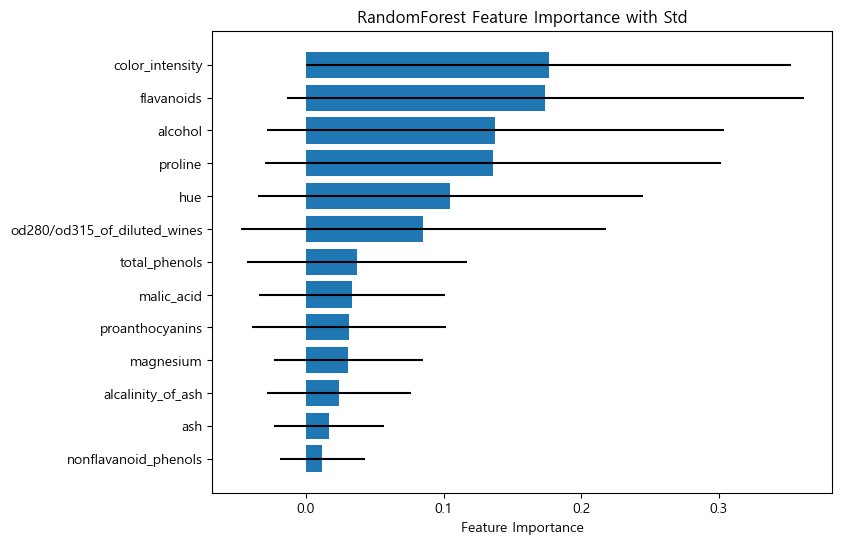

In [19]:
import matplotlib.pyplot as plt
from matplotlib import rc
import platform

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    rc('font', family='AppleGothic')
elif platform.system() == 'Linux': # Colab 등
    rc('font', family='NanumBarunGothic')
    
plot_df = feature_importance_df.sort_values('importance')

plt.figure(figsize=(8, 6))
plt.barh(
    plot_df['feature'],
    plot_df['importance'],
    xerr=plot_df['std']
)
plt.xlabel('Feature Importance')
plt.title('RandomForest Feature Importance with Std')
plt.show()

#### 실험
---

In [33]:
# decision Tree

decision_depth_result = []

for depth in range(1,11):
    dt_pipe = Pipeline([
        ('model', DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        ))
    ])

    scores = cross_validate(
            dt_pipe,
            train_wine,
            train_target,
            cv=5,
            return_train_score=True,
            scoring='f1_macro'
        )

    decision_depth_result.append({
        'max_depth': depth,
        'train_f1': scores['train_score'].mean(),
        'test_f1': scores['test_score'].mean(),
        'gap': scores['train_score'].mean() - scores['test_score'].mean()
    })

depth_df = pd.DataFrame(decision_depth_result)
depth_df.sort_values('test_f1', ascending=False)


,max_depth,train_f1,test_f1,gap
2,3,0.994794,0.948519,0.046275
3,4,1.000000,0.941111,0.058889
6,7,1.000000,0.941111,0.058889
7,8,1.000000,0.941111,0.058889
4,5,1.000000,0.941111,0.058889
5,6,1.000000,0.941111,0.058889
8,9,1.000000,0.941111,0.058889
9,10,1.000000,0.941111,0.058889
1,2,0.946726,0.905243,0.041483
0,1,0.520975,0.509363,0.011612


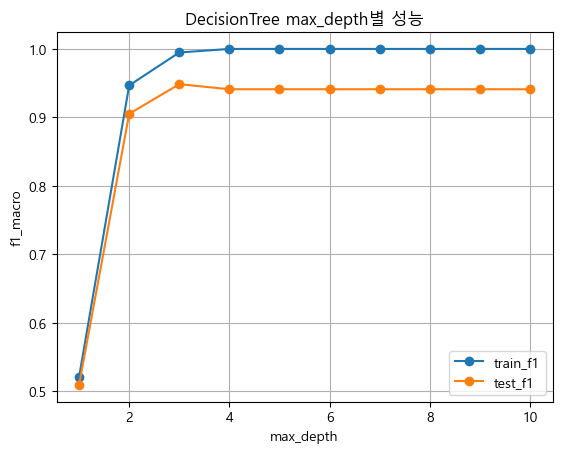

In [ ]:
plt.plot(depth_df['max_depth'], depth_df['train_f1'], marker='o', label='train_f1')
plt.plot(depth_df['max_depth'], depth_df['test_f1'], marker='o', label='test_f1')

plt.xlabel('max_depth')
plt.ylabel('f1_macro')
plt.title('DecisionTree max_depth별 성능')
plt.legend()
plt.grid(True)
plt.show()

In [36]:
# Random Forest

rf_result = []

for depth in [None, 2, 3, 4, 5, 7, 10]:
    rf_pipe = Pipeline([
        ('model', RandomForestClassifier(
            max_depth=depth,
            random_state=42,
            n_jobs=-1
        ))
    ])

    scores = cross_validate(
        rf_pipe,
        train_wine,
        train_target,
        cv=5,
        return_train_score=True,
        scoring='f1_macro'
    )

    rf_result.append({
        'max_depth': depth,
        'train_f1': scores['train_score'].mean(),
        'valid_f1': scores['test_score'].mean(),
        'gap': scores['train_score'].mean() - scores['test_score'].mean()
    })

rf_df = pd.DataFrame(rf_result)
rf_df.sort_values('valid_f1', ascending=False)

,max_depth,train_f1,valid_f1,gap
0,NaN,1.000000,0.970389,0.029611
2,3.0,1.000000,0.970389,0.029611
3,4.0,1.000000,0.970389,0.029611
5,7.0,1.000000,0.970389,0.029611
4,5.0,1.000000,0.970389,0.029611
6,10.0,1.000000,0.970389,0.029611
1,2.0,0.990695,0.963706,0.026989


In [37]:
# XGBoost

xgb_result = []

for depth in range(1, 8):
    xgb_pipe = Pipeline([
        ('model', XGBClassifier(
            max_depth=depth,
            random_state=42,
            eval_metric='mlogloss'
        ))
    ])

    scores = cross_validate(
        xgb_pipe,
        train_wine,
        train_target,
        cv=5,
        return_train_score=True,
        scoring='f1_macro'
    )

    xgb_result.append({
        'max_depth': depth,
        'train_f1': scores['train_score'].mean(),
        'valid_f1': scores['test_score'].mean(),
        'gap': scores['train_score'].mean() - scores['test_score'].mean()
    })

xgb_df = pd.DataFrame(xgb_result)
xgb_df.sort_values('valid_f1', ascending=False)

,max_depth,train_f1,valid_f1,gap
0,1,1.0,0.971561,0.028439
2,3,1.0,0.948184,0.051816
3,4,1.0,0.948184,0.051816
5,6,1.0,0.948184,0.051816
4,5,1.0,0.948184,0.051816
6,7,1.0,0.948184,0.051816
1,2,1.0,0.947927,0.052073


#### GridSearchCV 로 Max depth 찾기
---

In [39]:
dt_pipe = Pipeline([
    ('model', DecisionTreeClassifier(random_state=42))
])

params = {
    'model__max_depth': range(1, 11),
    'model__min_samples_leaf': [1, 2, 3, 5, 10]
}

gs = GridSearchCV(
    dt_pipe,
    params,
    cv=5,
    scoring='f1_macro',
    return_train_score=True
)

gs.fit(train_wine, train_target)

print(gs.best_params_)
print(gs.best_score_)

{'model__max_depth': 3, 'model__min_samples_leaf': 1}
0.9485186881539015
